In [12]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
def horizontal_fill(image_path):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found or invalid format.")

    height, width = img.shape[:2]
    center_col = width // 2

    # Get the pixel column at the center
    center_column = img[:, center_col:center_col+1]  # shape: (height, 1, 3)

    # Fill left half with this column
    for col in range(0, center_col):
        img[:, col:col+1] = center_column

    # Save the result
    return img


In [170]:
imgs = os.listdir('imgs')

In [172]:
imgs

['IMG_2561.JPG',
 'IMG_2562.JPG',
 'IMG_2563.JPG',
 'IMG_2564.JPG',
 'IMG_2805_c.jpg',
 'IMG_2805_c.png',
 'C6BEC9D9-897C-4014-92EB-331F85591A0B.JPG',
 'IMG_2734.jpg',
 'IMG_2642.JPG',
 '13B56C6E-1D0D-4700-829F-8442768EB038.JPG',
 'IMG_2805.jpg',
 'IMG_2780.JPG',
 'IMG_2594.JPG',
 'IMG_2744.JPG',
 'IMG_2828.JPG',
 'IMG_2790.JPG']

In [14]:
i = os.path.join('imgs',random.choices(imgs)[0])
print(i)

imgs/IMG_2790.JPG


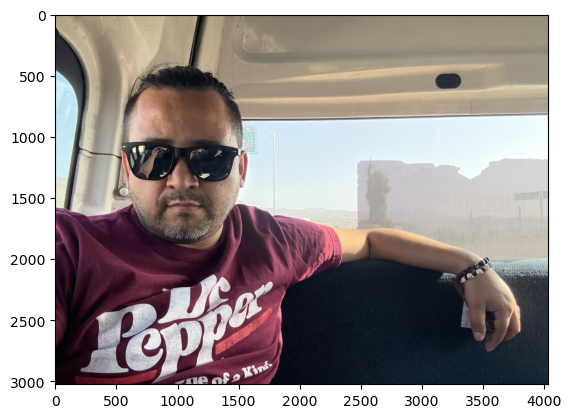

In [18]:
img = cv2.imread(i)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [22]:
hf = horizontal_fill(i)

In [24]:
hf_rgb = cv2.cvtColor(hf,cv2.COLOR_BGR2RGB)

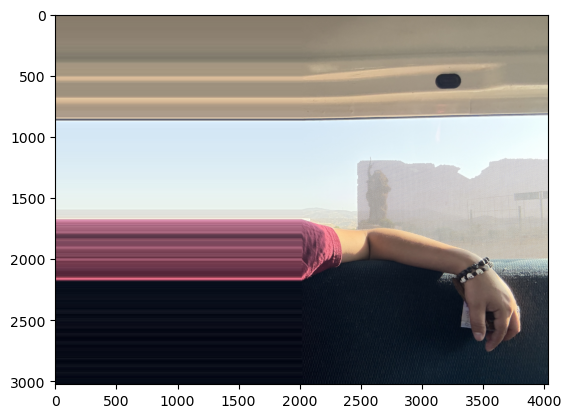

In [26]:
plt.imshow(hf_rgb)

In [164]:
def fill_with_edge_color(image_path, fill_percent=0.5, fill_direction='left'):
    # Load the image
    img = cv2.imread(image_path,cv2.IMREAD_UNCHANGED)
    img = img[:, :, 0:3]
    if img is None:
        raise ValueError("Image not found or invalid format.")

    height, width = img.shape[:2]
    fill_percent = max(0.0, min(1.0, fill_percent))  # clamp 0–1

    if fill_direction == 'left':
        fill_width = int(width * fill_percent)
        source_col = min(fill_width, width - 1)
        column = img[:, source_col:source_col + 1]
        for col in range(fill_width):
            img[:, col:col + 1] = column

    elif fill_direction == 'right':
        fill_width = int(width * fill_percent)
        source_col = max(width - fill_width - 1, 0)
        column = img[:, source_col:source_col + 1]
        for col in range(width - fill_width, width):
            img[:, col:col + 1] = column

    elif fill_direction == 'up':
        fill_height = int(height * fill_percent)
        source_row = min(fill_height, height - 1)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(fill_height):
            img[row_idx:row_idx + 1, :] = row

    elif fill_direction == 'down':
        fill_height = int(height * fill_percent)
        source_row = max(height - fill_height - 1, 0)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(height - fill_height, height):
            img[row_idx:row_idx + 1, :] = row

    else:
        raise ValueError("fill_direction must be one of: 'left', 'right', 'up', 'down'.")

    return img

In [88]:
f = fill_with_edge_color(i,.26,'left')

In [90]:
f_rgb = cv2.cvtColor(f,cv2.COLOR_BGR2RGB)

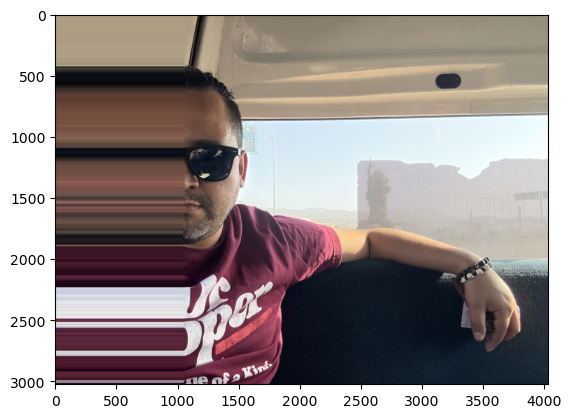

In [92]:
plt.imshow(f_rgb)

In [98]:
ppath = 'imgs/IMG_2561.JPG'

In [106]:
p= fill_with_edge_color(ppath,.26,'left')

In [108]:
p_rgb = cv2.cvtColor(p,cv2.COLOR_BGR2RGB)

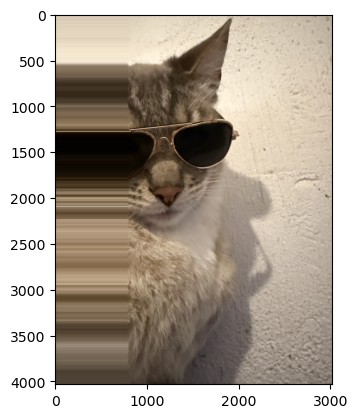

In [110]:
plt.imshow(p_rgb)

In [178]:

ypath = 'imgs/IMG_2805.JPG'
y= fill_with_edge_color(ypath,.47,'right')
y_rgb = cv2.cvtColor(y,cv2.COLOR_BGR2RGB)

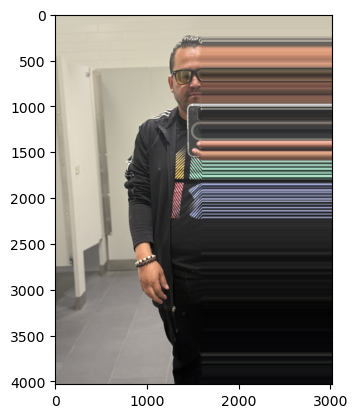

In [180]:
plt.imshow(y_rgb)

In [198]:
ypath = 'imgs/IMG_2805_c.jpg'
y= fill_with_edge_color(ypath,.65,'right')
y_rgb = cv2.cvtColor(y,cv2.COLOR_BGR2RGB)

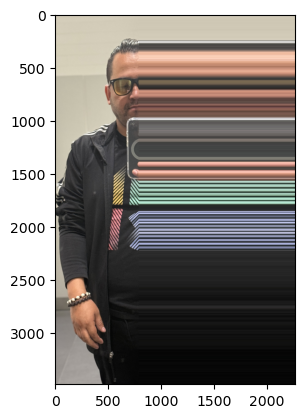

In [200]:
plt.imshow(y_rgb)

In [206]:
cv2.imwrite("hyo.png",y)

True